# Airfoil geometry generation

This code can be used to generate an airfoil profile based on the NACA or the bezier curves

In [1]:
%load_ext autoreload
%autoreload 2

import sys
import os

sys.path.append(os.path.abspath(".."))

from src.geometry import AirfoilGeometry

Failed to read module file 'C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.12_3.12.2800.0_x64__qbz5n2kfra8p0\Lib\functools.py' for module 'functools': UnicodeDecodeError
Traceback (most recent call last):
  File "c:\Users\bertr\Documents\Code\Foil-Optimization-AI\.venv\Lib\site-packages\IPython\core\extensions.py", line 62, in load_extension
    return self._load_extension(module_str)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\bertr\Documents\Code\Foil-Optimization-AI\.venv\Lib\site-packages\IPython\core\extensions.py", line 77, in _load_extension
    mod = import_module(module_str)
          ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.12_3.12.2800.0_x64__qbz5n2kfra8p0\Lib\importlib\__init__.py", line 90, in import_module
    return _bootstrap._gcd_import(name[level:], package, level)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "<frozen importlib._bootstrap>", line 1387, in

## The NACA config

NACA is based on 4-digits numbers

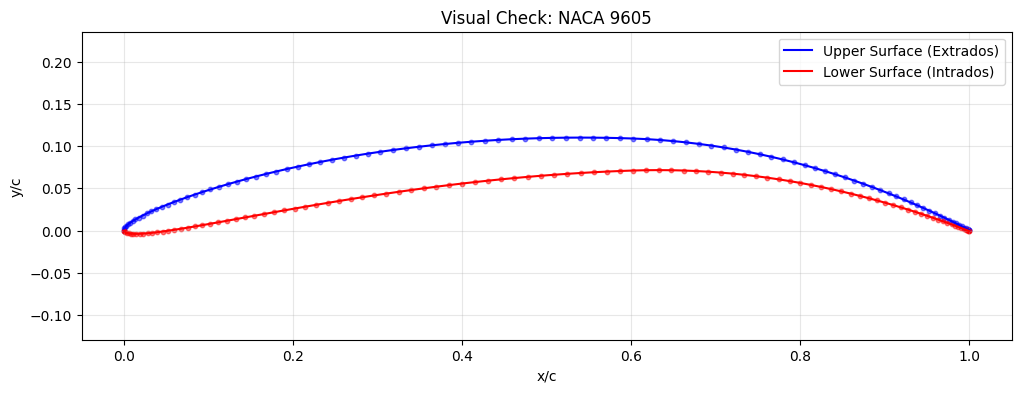

In [2]:
max_camber = 9              # [0  ;  95]
max_camber_position = 6     # [0  ;   9]
thickness = 5               # [1  ;  40]
number_points = 100         # [20 ; 200]

geo = AirfoilGeometry(n_points=number_points)
xu, yu, xl, yl = geo.generate_naca4(m_int=max_camber, p_int=max_camber_position, t_int=thickness)

geo.plot_naca4(m=max_camber, p=max_camber_position, t=thickness)

## The Bezier Curve config

Bezier curves are based on a cloud of points that are shaping the curves

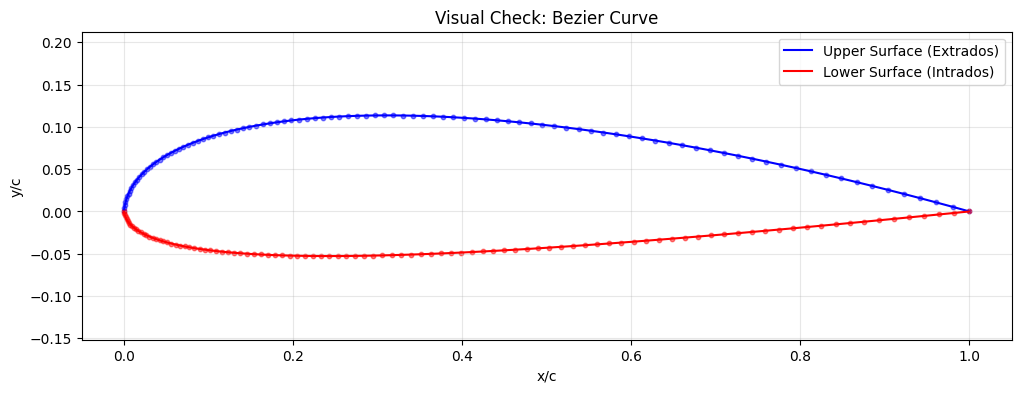

In [3]:
# Upper Surface: Notice the second point (0.01, 0.12)
# This forces the curve to go UP almost vertically before curving back.
top_pts = [
    (0.0, 0.0),      # Leading Edge
    (0.01, 0.12),    # Control 1: High and very close to LE (creates roundness)
    (0.35, 0.18),    # Control 2: Max thickness area
    (1.0, 0.0)       # Trailing Edge
]

# Lower Surface: Mirroring the logic for a rounded bottom
bottom_pts = [
    (0.0, 0.0),      # Leading Edge
    (0.01, -0.08),   # Control 1: Rounding the bottom LE
    (0.40, -0.06),   # Control 2: Flatter bottom
    (1.0, 0.0)       # Trailing Edge
]

number_points = 100         # [20; 200]

geo = AirfoilGeometry(n_points=number_points)
xu, yu, xl, yl = geo.generate_bezier(top_pts, bottom_pts)
geo.plot_bezier(top_pts, bottom_pts)
